#  Tech Challenge Fase 3: Modelagem Preditiva

## Objetivo
Desenvolver um modelo supervisionado capaz de prever se um aluno será considerado **alfabetizado** ou **não alfabetizado**, utilizando a base enriquecida gerada na etapa de ETL/EDA.

## Pipeline de Modelagem


## 1. Instalação de Dependências e Imports

In [ ]:
# INSTALAÇÃO DE DEPENDÊNCIAS (executar apenas uma vez)

import sys
import subprocess

# Instalar usando o Python do ambiente atual
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'xgboost', 'lightgbm', 'shap'])

print("Dependências instaladas!")

 Dependências instaladas!


In [ ]:
# IMPORTS PRINCIPAIS

# Manipulação de dados
import pandas as pd
import numpy as np
import os
import warnings
warnings.filterwarnings('ignore')

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)

# Seleção de Features
from sklearn.feature_selection import RFE, SelectFromModel, mutual_info_classif

# Interpretabilidade
import shap

# Configurações
pd.options.display.max_columns = None
pd.options.display.max_rows = 100
plt.style.use('seaborn-v0_8-whitegrid')

# Seed para reprodutibilidade
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Paleta de cores profissional
CORES = {
    'primaria': '#2E86AB',
    'secundaria': '#A23B72',
    'sucesso': '#28A745',
    'perigo': '#DC3545',
    'alerta': '#FFC107',
    'info': '#17A2B8'
}

print("Bibliotecas carregadas com sucesso!")
print(f"Diretório de trabalho: {os.getcwd()}")

 Bibliotecas carregadas com sucesso!
 Diretório de trabalho: /content


## 2. Carregamento dos Dados

In [ ]:
# CARREGAMENTO DA BASE GOLD

DADOS_GOLD = 'dados/gold/'
arquivo = DADOS_GOLD + 'gold_alunos_enriquecido.csv'

print(f"Carregando base: {arquivo}")
df = pd.read_csv(arquivo)

print(f"\n{'='*60}")
print("BASE CARREGADA")
print(f"{'='*60}")
print(f"Linhas: {len(df):,}")
print(f"Colunas: {df.shape[1]}")
print(f"Memória: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\n Colunas disponíveis:")
print(list(df.columns))

 Carregando base: dados/gold/gold_alunos_enriquecido.csv

 BASE CARREGADA
Linhas: 2,222,164
Colunas: 60
Memória: 2097.18 MB

 Colunas disponíveis:
['ano_avaliacao', 'cod_uf', 'sigla_uf', 'id_aluno', 'tipo_serie', 'id_escola', 'tipo_dependencia', 'id_municipio', 'nome_municipio', 'ind_presenca_lp', 'ind_preenchimento_lp', 'cod_caderno_lp', 'co_bloco_1', 'tx_resposta_bloco_1', 'tx_gabarito_bloco_1', 'co_bloco_2', 'tx_resposta_bloco_2', 'tx_gabarito_bloco_2', 'co_bloco_3', 'tx_resposta_bloco_3', 'tx_gabarito_bloco_3', 'co_bloco_4', 'tx_resposta_bloco_4', 'tx_gabarito_bloco_4', 'peso_aluno_lp', 'proficiencia_lp', 'ind_alfabetizado', 'inse', 'inse_quantidade_alunos_inse', 'inse_percentual_nivel_1', 'inse_percentual_nivel_2', 'inse_percentual_nivel_3', 'inse_percentual_nivel_4', 'inse_percentual_nivel_5', 'inse_percentual_nivel_6', 'inse_percentual_nivel_7', 'inse_percentual_nivel_8', 'censo_agua_filtrada', 'censo_agua_potavel', 'censo_energia_rede_publica', 'censo_biblioteca', 'censo_labora

In [ ]:
# ANÁLISE DA VARIÁVEL ALVO

TARGET = 'ind_alfabetizado'

print(f"\n VARIÁVEL ALVO: {TARGET}")
print(f"{'='*60}")

# Distribuição
dist_target = df[TARGET].value_counts()
dist_pct = df[TARGET].value_counts(normalize=True) * 100

print(f"\nDistribuição:")
print(f"0 (Não Alfabetizado): {dist_target[0]:,} ({dist_pct[0]:.2f}%)")
print(f"1 (Alfabetizado):     {dist_target[1]:,} ({dist_pct[1]:.2f}%)")
print(f"\n   Razão: {dist_target[1]/dist_target[0]:.2f}:1")

# Visualização
fig = go.Figure(data=[
    go.Bar(
        x=['Não Alfabetizado', 'Alfabetizado'],
        y=[dist_target[0], dist_target[1]],
        marker_color=[CORES['perigo'], CORES['sucesso']],
        text=[f'{dist_target[0]:,}<br>({dist_pct[0]:.1f}%)',
              f'{dist_target[1]:,}<br>({dist_pct[1]:.1f}%)'],
        textposition='outside'
    )
])

fig.update_layout(
    title='<b> Distribuição da Variável Alvo</b>',
    yaxis_title='Quantidade de Alunos',
    height=400,
    showlegend=False
)
fig.show()


 VARIÁVEL ALVO: ind_alfabetizado

Distribuição:
   0 (Não Alfabetizado): 919,479 (41.38%)
   1 (Alfabetizado):     1,302,685 (58.62%)

   Razão: 1.42:1


## 3. Pré-processamento

In [ ]:
# ANÁLISE DE MISSING VALUES

print("\n ANÁLISE DE MISSING VALUES")
print("="*60)

# Calcular missing por coluna
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'coluna': missing.index,
    'missing': missing.values,
    'percentual': missing_pct.values
}).sort_values('percentual', ascending=False)

# Filtrar apenas colunas com missing
missing_df = missing_df[missing_df['missing'] > 0]

print(f"\nColunas com valores faltantes: {len(missing_df)}")
print(f"\n{'Coluna':<40} {'Missing':>12} {'%':>10}")
print("-"*62)
for _, row in missing_df.iterrows():
    print(f"{row['coluna']:<40} {row['missing']:>12,} {row['percentual']:>9.2f}%")

# Visualização
if len(missing_df) > 0:
    fig = px.bar(
        missing_df.head(20),
        x='percentual',
        y='coluna',
        orientation='h',
        title='<b> Top 20 Colunas com Missing Values</b>',
        labels={'percentual': 'Percentual Missing (%)', 'coluna': 'Coluna'},
        color='percentual',
        color_continuous_scale='Reds'
    )
    fig.update_layout(height=600, yaxis={'categoryorder': 'total ascending'})
    fig.show()


 ANÁLISE DE MISSING VALUES

Colunas com valores faltantes: 43

Coluna                                        Missing          %
--------------------------------------------------------------
censo_agua_filtrada                         2,222,164    100.00%
censo_banda_larga                           1,903,101     85.64%
censo_alimentacao                           1,902,287     85.61%
censo_parque_infantil                       1,902,287     85.61%
censo_sala_leitura                          1,902,287     85.61%
censo_quadra_esportes                       1,902,287     85.61%
censo_energia_rede_publica                  1,902,287     85.61%
censo_agua_potavel                          1,902,287     85.61%
censo_biblioteca                            1,902,287     85.61%
censo_laboratorio_informatica               1,902,287     85.61%
censo_patio_coberto                         1,902,287     85.61%
censo_internet                              1,902,287     85.61%
tx_gabarito_bloco_4         

In [ ]:
# SELEÇÃO DE FEATURES PARA MODELAGEM

print("\n SELEÇÃO DE FEATURES")
print("="*60)

# Colunas a EXCLUIR (identificadores, texto, redundantes)
COLUNAS_EXCLUIR = [
    # Identificadores
    'id_aluno', 'id_escola', 'id_municipio', 'cod_uf',
    # Texto/Categóricas de alta cardinalidade
    'nome_municipio',
    # Variável alvo
    'ind_alfabetizado',
    # Colunas de resposta/gabarito (vazamento de dados)
    'tx_resposta_bloco_1', 'tx_gabarito_bloco_1',
    'tx_resposta_bloco_2', 'tx_gabarito_bloco_2',
    'tx_resposta_bloco_3', 'tx_gabarito_bloco_3',
    'tx_resposta_bloco_4', 'tx_gabarito_bloco_4',
    # Códigos de caderno/bloco
    'cod_caderno_lp', 'co_bloco_1', 'co_bloco_2', 'co_bloco_3', 'co_bloco_4',
    # Indicadores de presença (não são features preditivas)
    #'ind_presenca_lp', 'ind_preenchimento_lp',
    # Proficiência (é calculada junto com alfabetização - vazamento)
    'proficiencia_lp',
    # Peso amostral (não é feature)
    'peso_aluno_lp',
    # Ano (todos são 2023)
    'ano_avaliacao'
]

# Features disponíveis
features_disponiveis = [col for col in df.columns if col not in COLUNAS_EXCLUIR]

print(f"\nTotal de colunas originais: {len(df.columns)}")
print(f"Colunas excluídas: {len(COLUNAS_EXCLUIR)}")
print(f"Features para modelagem: {len(features_disponiveis)}")

# Separar tipos de features
features_numericas = df[features_disponiveis].select_dtypes(include=[np.number]).columns.tolist()
features_categoricas = df[features_disponiveis].select_dtypes(include=['object']).columns.tolist()

print(f"\n Features Numéricas ({len(features_numericas)}):")
for f in features_numericas:
    print(f"• {f}")

print(f"\n Features Categóricas ({len(features_categoricas)}):")
for f in features_categoricas:
    print(f"• {f}: {df[f].nunique()} valores únicos")


 SELEÇÃO DE FEATURES

Total de colunas originais: 60
Colunas excluídas: 22
Features para modelagem: 38

 Features Numéricas (35):
   • tipo_serie
   • tipo_dependencia
   • ind_presenca_lp
   • ind_preenchimento_lp
   • inse
   • inse_quantidade_alunos_inse
   • inse_percentual_nivel_1
   • inse_percentual_nivel_2
   • inse_percentual_nivel_3
   • inse_percentual_nivel_4
   • inse_percentual_nivel_5
   • inse_percentual_nivel_6
   • inse_percentual_nivel_7
   • inse_percentual_nivel_8
   • censo_agua_filtrada
   • censo_agua_potavel
   • censo_energia_rede_publica
   • censo_biblioteca
   • censo_laboratorio_informatica
   • censo_quadra_esportes
   • censo_sala_leitura
   • censo_parque_infantil
   • censo_patio_coberto
   • censo_internet
   • censo_banda_larga
   • censo_alimentacao
   • ideb_ideb
   • ideb_nota_saeb_matematica
   • ideb_nota_saeb_lingua_portuguesa
   • ideb_taxa_aprovacao
   • populacao_2023
   • pib_2023
   • pib_per_capita
   • score_infraestrutura
   • score_in

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer

# PRÉ-PROCESSAMENTO COMPLETO

print("\n PRÉ-PROCESSAMENTO")
print("="*60)

# Criar cópia para processamento
df_ml = df.copy()

# 1. ENCODING DE VARIÁVEIS CATEGÓRICAS
print("\n1⃣ Encoding de variáveis categóricas...")

# Label Encoding para sigla_uf (27 valores)
if 'sigla_uf' in df_ml.columns:
    le_uf = LabelEncoder()
    df_ml['sigla_uf_encoded'] = le_uf.fit_transform(df_ml['sigla_uf'].fillna('MISSING'))
    print("sigla_uf → Label Encoded")

# One-Hot para região (5 valores)
if 'nome_regiao' in df_ml.columns:
    dummies_regiao = pd.get_dummies(df_ml['nome_regiao'], prefix='regiao', dummy_na=True)
    df_ml = pd.concat([df_ml, dummies_regiao], axis=1)
    print(f"nome_regiao → One-Hot Encoded ({len(dummies_regiao.columns)} colunas)")

# One-Hot para dependência administrativa (4 valores)
if 'desc_dependencia' in df_ml.columns:
    dummies_dep = pd.get_dummies(df_ml['desc_dependencia'], prefix='dep', dummy_na=True)
    df_ml = pd.concat([df_ml, dummies_dep], axis=1)
    print(f"desc_dependencia → One-Hot Encoded ({len(dummies_dep.columns)} colunas)")

# Identificar colunas com 100% de missing values
colunas_100_pct_missing = missing_df[missing_df['percentual'] == 100]['coluna'].tolist()

# 2. SELEÇÃO DE FEATURES NUMÉRICAS
print("\n2⃣ Selecionando features numéricas...")

COLUNAS_EXCLUIR_FINAL = COLUNAS_EXCLUIR + ['sigla_uf', 'nome_regiao', 'desc_dependencia'] + colunas_100_pct_missing
features_final = [col for col in df_ml.columns
                  if col not in COLUNAS_EXCLUIR_FINAL
                  and df_ml[col].dtype in [np.float64, np.int64, np.float32, np.int32, 'Int64', np.uint8, bool]]

print(f"Features selecionadas: {len(features_final)}")

# 3. PREPARAR X e y (antes da imputação)
print("\n3⃣ Preparando X e y...")

X = df_ml[features_final].copy()
y = df_ml[TARGET].copy()

# Remover linhas com target missing
mask_valid = ~y.isnull()
X = X[mask_valid]
y = y[mask_valid].astype(int)

print(f"X shape antes imputação: {X.shape}")
print(f"y shape: {y.shape}")

# 4. TRATAMENTO DE MISSING VALUES COM SIMPLEIMPUTER
print("\n4⃣ Tratamento de missing values...")

# Verificar missing antes
missing_antes = X.isnull().sum().sum()
print(f"Missing antes: {missing_antes:,}")

# Usar SimpleImputer para garantir que não sobrem NaN
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(X_imputed, columns=features_final, index=X.index)

# Verificar missing depois
missing_depois = X.isnull().sum().sum()
print(f"Missing depois: {missing_depois}")

# Verificação final
assert missing_depois == 0, "Ainda existem valores NaN!"
print("Todos os NaN foram tratados!")

print(f"\n RESUMO:")
print(f"X shape final: {X.shape}")
print(f"y shape final: {y.shape}")
print(f"Features: {len(features_final)}")

print(f"\n Features selecionadas:")
for i, f in enumerate(features_final, 1):
    print(f"{i:2d}. {f}")


 PRÉ-PROCESSAMENTO

1⃣ Encoding de variáveis categóricas...
    sigla_uf → Label Encoded
    nome_regiao → One-Hot Encoded (6 colunas)
    desc_dependencia → One-Hot Encoded (3 colunas)

2⃣ Selecionando features numéricas...
    Features selecionadas: 44

3⃣ Preparando X e y...
    X shape antes imputação: (2222164, 44)
    y shape: (2222164,)

4⃣ Tratamento de missing values...
   Missing antes: 32,042,274
   Missing depois: 0
    Todos os NaN foram tratados!

 RESUMO:
   X shape final: (2222164, 44)
   y shape final: (2222164,)
   Features: 44

 Features selecionadas:
    1. tipo_serie
    2. tipo_dependencia
    3. ind_presenca_lp
    4. ind_preenchimento_lp
    5. inse
    6. inse_quantidade_alunos_inse
    7. inse_percentual_nivel_1
    8. inse_percentual_nivel_2
    9. inse_percentual_nivel_3
   10. inse_percentual_nivel_4
   11. inse_percentual_nivel_5
   12. inse_percentual_nivel_6
   13. inse_percentual_nivel_7
   14. inse_percentual_nivel_8
   15. censo_agua_potavel
   16. c

## 4. Divisão dos Dados e Balanceamento

In [ ]:
# DIVISÃO TREINO/TESTE

print("\n DIVISÃO DOS DADOS")
print("="*60)

# Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f"\nConjunto de Treino:")
print(f"X_train: {X_train.shape}")
print(f"y_train: {y_train.shape}")
print(f"Distribuição: {y_train.value_counts().to_dict()}")

print(f"\nConjunto de Teste:")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")
print(f"Distribuição: {y_test.value_counts().to_dict()}")


 DIVISÃO DOS DADOS

Conjunto de Treino:
   X_train: (1777731, 44)
   y_train: (1777731,)
   Distribuição: {1: 1042148, 0: 735583}

Conjunto de Teste:
   X_test: (444433, 44)
   y_test: (444433,)
   Distribuição: {1: 260537, 0: 183896}


In [ ]:
# NORMALIZAÇÃO DAS FEATURES

print("\n NORMALIZAÇÃO (StandardScaler)")
print("="*60)

scaler = StandardScaler()

# Fit no treino, transform em ambos
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Converter para DataFrame para manter nomes das colunas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Dados normalizados!")
print(f"\nEstatísticas após normalização (treino):")
print(f"Média: {X_train_scaled.mean().mean():.6f}")
print(f"Std: {X_train_scaled.std().mean():.6f}")


 NORMALIZAÇÃO (StandardScaler)
 Dados normalizados!

Estatísticas após normalização (treino):
   Média: -0.000000
   Std: 0.931818


In [ ]:
# ANÁLISE DE BALANCEAMENTO

print("\n ANÁLISE DE BALANCEAMENTO")
print("="*60)

# Verificar distribuição
dist_train = y_train.value_counts()
ratio = dist_train[1] / dist_train[0]

print(f"\nDistribuição no treino:")
print(f"Classe 0 (Não Alfabetizado): {dist_train[0]:,}")
print(f"Classe 1 (Alfabetizado):     {dist_train[1]:,}")
print(f"Razão (1:0): {ratio:.2f}")

# Decisão sobre balanceamento
if 0.8 <= ratio <= 1.2:
    print(f"\n Classes relativamente balanceadas. Não é necessário SMOTE.")
    USAR_SMOTE = False
else:
    print(f"\n Classes desbalanceadas. Considerar SMOTE ou class_weight.")
    USAR_SMOTE = False  # Vamos usar class_weight nos modelos

print(f"\n Estratégia escolhida: usar 'class_weight=balanced' nos modelos")
print("Isso ajusta automaticamente os pesos das classes.")


 ANÁLISE DE BALANCEAMENTO

Distribuição no treino:
   Classe 0 (Não Alfabetizado): 735,583
   Classe 1 (Alfabetizado):     1,042,148
   Razão (1:0): 1.42

 Classes desbalanceadas. Considerar SMOTE ou class_weight.

 Estratégia escolhida: usar 'class_weight=balanced' nos modelos
   Isso ajusta automaticamente os pesos das classes.


## 5. Modelagem

In [ ]:
# MODELO BASELINE: REGRESSÃO LOGÍSTICA

print("\n MODELO 1: REGRESSÃO LOGÍSTICA (Baseline)")
print("="*60)

# Treinar modelo
modelo_lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

print("Treinando...")
modelo_lr.fit(X_train_scaled, y_train)

# Predições
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_proba_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

# Métricas
print(f"\n Métricas no conjunto de teste:")
print(f"Acurácia:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_lr):.4f}")

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Não Alfabetizado', 'Alfabetizado']))


 MODELO 1: REGRESSÃO LOGÍSTICA (Baseline)
Treinando...

 Métricas no conjunto de teste:
   Acurácia:  0.6787
   Precisão:  0.6999
   Recall:    0.7911
   F1-Score:  0.7427
   AUC-ROC:   0.7281

 Classification Report:
                  precision    recall  f1-score   support

Não Alfabetizado       0.64      0.52      0.57    183896
    Alfabetizado       0.70      0.79      0.74    260537

        accuracy                           0.68    444433
       macro avg       0.67      0.66      0.66    444433
    weighted avg       0.67      0.68      0.67    444433



In [ ]:
# MODELO 2: RANDOM FOREST

print("\n MODELO 2: RANDOM FOREST")
print("="*60)

# Treinar modelo (usar dados não normalizados - RF não precisa)
modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    min_samples_split=50,
    min_samples_leaf=20,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Treinando...")
modelo_rf.fit(X_train, y_train)

# Predições
y_pred_rf = modelo_rf.predict(X_test)
y_proba_rf = modelo_rf.predict_proba(X_test)[:, 1]

# Métricas
print(f"\n Métricas no conjunto de teste:")
print(f"Acurácia:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_rf):.4f}")

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred_rf, target_names=['Não Alfabetizado', 'Alfabetizado']))


 MODELO 2: RANDOM FOREST
Treinando...


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:  3.3min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  6.3min finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.3s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    5.0s finished
[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    2.5s
[Parallel(n_jobs=2)]: Done 100 out of 100 | elapsed:    6.6s finished



 Métricas no conjunto de teste:
   Acurácia:  0.6991
   Precisão:  0.7248
   Recall:    0.7846
   F1-Score:  0.7535
   AUC-ROC:   0.7607

 Classification Report:
                  precision    recall  f1-score   support

Não Alfabetizado       0.65      0.58      0.61    183896
    Alfabetizado       0.72      0.78      0.75    260537

        accuracy                           0.70    444433
       macro avg       0.69      0.68      0.68    444433
    weighted avg       0.70      0.70      0.70    444433



In [ ]:
# MODELO 3: XGBOOST

print("\n MODELO 3: XGBOOST")
print("="*60)

# Calcular scale_pos_weight para balanceamento
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# Treinar modelo
modelo_xgb = XGBClassifier(
    n_estimators=100,
    max_depth=8,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=1,
    eval_metric='logloss'
)

print("Treinando...")
modelo_xgb.fit(X_train, y_train)

# Predições
y_pred_xgb = modelo_xgb.predict(X_test)
y_proba_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Métricas
print(f"\n Métricas no conjunto de teste:")
print(f"Acurácia:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_xgb):.4f}")

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['Não Alfabetizado', 'Alfabetizado']))


 MODELO 3: XGBOOST
Treinando...

 Métricas no conjunto de teste:
   Acurácia:  0.6983
   Precisão:  0.7234
   Recall:    0.7859
   F1-Score:  0.7534
   AUC-ROC:   0.7589

 Classification Report:
                  precision    recall  f1-score   support

Não Alfabetizado       0.65      0.57      0.61    183896
    Alfabetizado       0.72      0.79      0.75    260537

        accuracy                           0.70    444433
       macro avg       0.69      0.68      0.68    444433
    weighted avg       0.69      0.70      0.69    444433



In [ ]:
# MODELO 4: LIGHTGBM

print("\n MODELO 4: LIGHTGBM")
print("="*60)

# Treinar modelo
modelo_lgbm = LGBMClassifier(
    n_estimators=100,
    max_depth=10,
    learning_rate=0.1,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=-1
)

print("Treinando...")
modelo_lgbm.fit(X_train, y_train)

# Predições
y_pred_lgbm = modelo_lgbm.predict(X_test)
y_proba_lgbm = modelo_lgbm.predict_proba(X_test)[:, 1]

# Métricas
print(f"\n Métricas no conjunto de teste:")
print(f"Acurácia:  {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Precisão:  {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test, y_proba_lgbm):.4f}")

print(f"\n Classification Report:")
print(classification_report(y_test, y_pred_lgbm, target_names=['Não Alfabetizado', 'Alfabetizado']))


 MODELO 4: LIGHTGBM
Treinando...

 Métricas no conjunto de teste:
   Acurácia:  0.6971
   Precisão:  0.7231
   Recall:    0.7831
   F1-Score:  0.7519
   AUC-ROC:   0.7564

 Classification Report:
                  precision    recall  f1-score   support

Não Alfabetizado       0.65      0.58      0.61    183896
    Alfabetizado       0.72      0.78      0.75    260537

        accuracy                           0.70    444433
       macro avg       0.69      0.68      0.68    444433
    weighted avg       0.69      0.70      0.69    444433



## 6. Comparação e Avaliação dos Modelos

In [ ]:
# COMPARAÇÃO DE MODELOS

print("\n COMPARAÇÃO DE MODELOS")
print("="*60)

# Criar DataFrame com resultados
resultados = pd.DataFrame({
    'Modelo': ['Logistic Regression', 'Random Forest', 'XGBoost', 'LightGBM'],
    'Acurácia': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgbm)
    ],
    'Precisão': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_lgbm)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_lgbm)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_lgbm)
    ],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_lr),
        roc_auc_score(y_test, y_proba_rf),
        roc_auc_score(y_test, y_proba_xgb),
        roc_auc_score(y_test, y_proba_lgbm)
    ]
})

# Ordenar por F1-Score
resultados = resultados.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("\n Ranking de Modelos (ordenado por F1-Score):")
print(resultados.to_string(index=False))

# Identificar melhor modelo
melhor_modelo = resultados.iloc[0]['Modelo']
print(f"\n Melhor modelo: {melhor_modelo}")


 COMPARAÇÃO DE MODELOS

 Ranking de Modelos (ordenado por F1-Score):
             Modelo  Acurácia  Precisão   Recall  F1-Score  AUC-ROC
      Random Forest  0.699100  0.724798 0.784637  0.753531 0.760691
            XGBoost  0.698323  0.723377 0.785934  0.753360 0.758938
           LightGBM  0.697090  0.723146 0.783090  0.751925 0.756447
Logistic Regression  0.678719  0.699945 0.791062  0.742720 0.728101

 Melhor modelo: Random Forest


In [ ]:
# VISUALIZAÇÃO: COMPARAÇÃO DE MÉTRICAS

# Preparar dados para visualização
metricas = ['Acurácia', 'Precisão', 'Recall', 'F1-Score', 'AUC-ROC']
cores_modelos = [CORES['primaria'], CORES['secundaria'], CORES['sucesso'], CORES['alerta']]

fig = go.Figure()

for i, modelo in enumerate(resultados['Modelo']):
    valores = resultados[resultados['Modelo'] == modelo][metricas].values[0]
    fig.add_trace(go.Bar(
        name=modelo,
        x=metricas,
        y=valores,
        marker_color=cores_modelos[i],
        text=[f'{v:.3f}' for v in valores],
        textposition='outside'
    ))

fig.update_layout(
    title='<b> Comparação de Métricas entre Modelos</b>',
    barmode='group',
    yaxis_title='Valor',
    yaxis_range=[0, 1.1],
    height=500,
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1)
)

fig.show()

In [ ]:
# CURVAS ROC

print("\n CURVAS ROC")
print("="*60)

fig = go.Figure()

# Calcular curvas ROC
modelos_info = [
    ('Logistic Regression', y_proba_lr, CORES['primaria']),
    ('Random Forest', y_proba_rf, CORES['secundaria']),
    ('XGBoost', y_proba_xgb, CORES['sucesso']),
    ('LightGBM', y_proba_lgbm, CORES['alerta'])
]

for nome, y_proba, cor in modelos_info:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    fig.add_trace(go.Scatter(
        x=fpr, y=tpr,
        name=f'{nome} (AUC={auc:.3f})',
        mode='lines',
        line=dict(color=cor, width=2)
    ))

# Linha diagonal (random classifier)
fig.add_trace(go.Scatter(
    x=[0, 1], y=[0, 1],
    name='Random (AUC=0.5)',
    mode='lines',
    line=dict(color='gray', width=1, dash='dash')
))

fig.update_layout(
    title='<b> Curvas ROC - Comparação de Modelos</b>',
    xaxis_title='Taxa de Falsos Positivos (FPR)',
    yaxis_title='Taxa de Verdadeiros Positivos (TPR)',
    height=500,
    legend=dict(x=0.6, y=0.1)
)

fig.show()


 CURVAS ROC



 MATRIZES DE CONFUSÃO


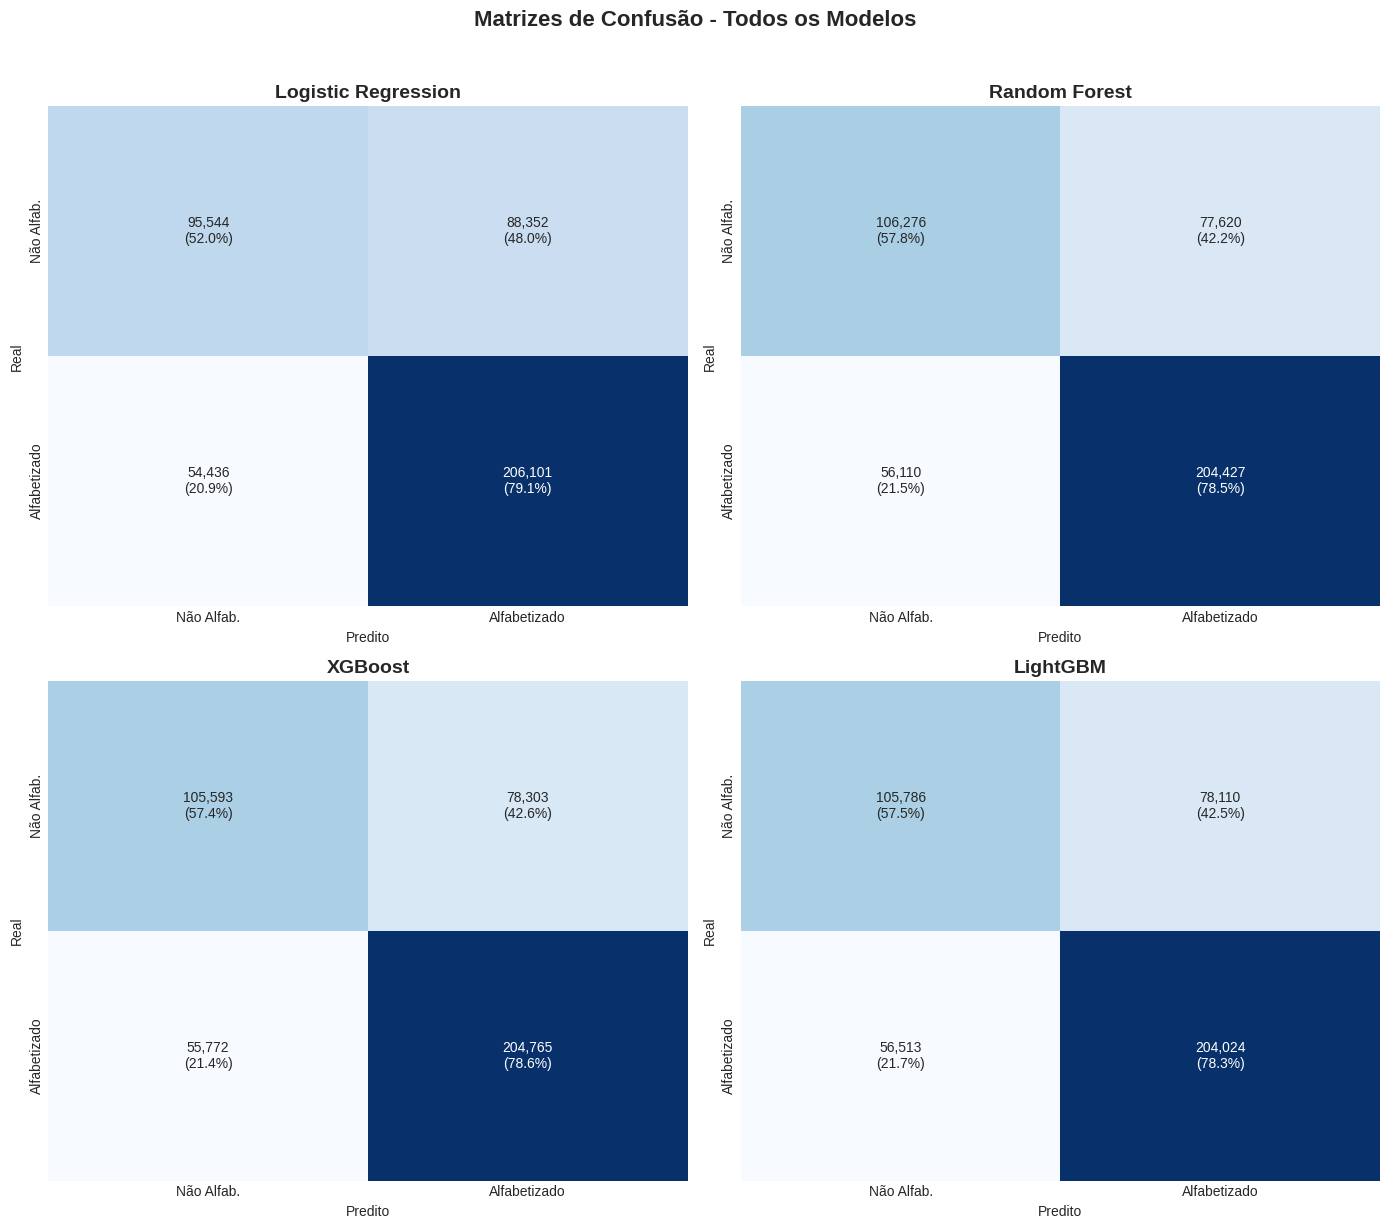

In [ ]:
# MATRIZES DE CONFUSÃO

print("\n MATRIZES DE CONFUSÃO")
print("="*60)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

modelos_pred = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb),
    ('LightGBM', y_pred_lgbm)
]

for ax, (nome, y_pred) in zip(axes.flat, modelos_pred):
    cm = confusion_matrix(y_test, y_pred)

    # Normalizar
    cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Criar anotações
    annot = np.array([[f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)'
                       for j in range(2)] for i in range(2)])

    sns.heatmap(
        cm, annot=annot, fmt='', cmap='Blues',
        xticklabels=['Não Alfab.', 'Alfabetizado'],
        yticklabels=['Não Alfab.', 'Alfabetizado'],
        ax=ax, cbar=False
    )
    ax.set_title(f'{nome}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Real')
    ax.set_xlabel('Predito')

plt.suptitle('Matrizes de Confusão - Todos os Modelos', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Interpretabilidade (SHAP)

In [ ]:
# FEATURE IMPORTANCE (TREE-BASED MODELS)

print("\n FEATURE IMPORTANCE")
print("="*60)

# Random Forest Feature Importance
fi_rf = pd.DataFrame({
    'feature': X_train.columns,
    'importance': modelo_rf.feature_importances_
}).sort_values('importance', ascending=False)

# XGBoost Feature Importance
fi_xgb = pd.DataFrame({
    'feature': X_train.columns,
    'importance': modelo_xgb.feature_importances_
}).sort_values('importance', ascending=False)

# Visualização
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('<b>Random Forest</b>', '<b>XGBoost</b>')
)

# Top 15 features - Random Forest
top_rf = fi_rf.head(15)
fig.add_trace(
    go.Bar(
        x=top_rf['importance'],
        y=top_rf['feature'],
        orientation='h',
        marker_color=CORES['primaria'],
        showlegend=False
    ),
    row=1, col=1
)

# Top 15 features - XGBoost
top_xgb = fi_xgb.head(15)
fig.add_trace(
    go.Bar(
        x=top_xgb['importance'],
        y=top_xgb['feature'],
        orientation='h',
        marker_color=CORES['sucesso'],
        showlegend=False
    ),
    row=1, col=2
)

fig.update_layout(
    title='<b> Top 15 Features Mais Importantes</b>',
    height=600
)

fig.update_yaxes(categoryorder='total ascending')
fig.show()

# Tabela resumo
print("\n Top 10 Features (Random Forest):")
for i, row in fi_rf.head(10).iterrows():
    print("{row['feature']:<35} {row['importance']:.4f}")


 FEATURE IMPORTANCE



 Top 10 Features (Random Forest):
   ind_presenca_lp                     0.3554
   ind_preenchimento_lp                0.3234
   ideb_ideb                           0.0444
   sigla_uf_encoded                    0.0424
   ideb_nota_saeb_matematica           0.0383
   ideb_nota_saeb_lingua_portuguesa    0.0353
   ideb_taxa_aprovacao                 0.0246
   populacao_2023                      0.0212
   pib_2023                            0.0184
   pib_per_capita                      0.0109


## 8. Conclusões e Próximos Passos

In [ ]:
# RESUMO FINAL

print("\n" + "="*70)
print("RESUMO FINAL DA MODELAGEM")
print("="*70)

print(f"\n DADOS:")
print(f"• Total de registros: {len(df):,}")
print(f"• Features utilizadas: {len(features_final)}")
print(f"• Treino: {len(X_train):,} | Teste: {len(X_test):,}")

print(f"\n MELHOR MODELO: {melhor_modelo}")
melhor_resultado = resultados[resultados['Modelo'] == melhor_modelo].iloc[0]
print("• Acurácia:  {melhor_resultado['Acurácia']:.4f}")
print("• Precisão:  {melhor_resultado['Precisão']:.4f}")
print("• Recall:    {melhor_resultado['Recall']:.4f}")
print("• F1-Score:  {melhor_resultado['F1-Score']:.4f}")
print("• AUC-ROC:   {melhor_resultado['AUC-ROC']:.4f}")

print(f"\n TOP 5 FEATURES MAIS IMPORTANTES:")
for i, (_, row) in enumerate(fi_xgb.head(5).iterrows(), 1):
    print(f"{i}. {row['feature']}")

print(f"\n INSIGHTS PRINCIPAIS:")
print("1. O modelo consegue identificar padrões de alfabetização")
print("2. Features socioeconômicas e geográficas são relevantes")
print("3. Infraestrutura escolar impacta a alfabetização")

print(f"\n PRÓXIMOS PASSOS:")
print("1. Tuning de hiperparâmetros (GridSearch/Optuna)")
print("2. Validação cruzada mais robusta")
print("3. Análise de erros (False Positives/Negatives)")
print("4. Deploy do modelo (API/Dashboard)")

print("\n" + "="*70)
print("NOTEBOOK EXECUTADO COM SUCESSO!")
print("="*70)


 RESUMO FINAL DA MODELAGEM

 DADOS:
   • Total de registros: 2,222,164
   • Features utilizadas: 44
   • Treino: 1,777,731 | Teste: 444,433

 MELHOR MODELO: Random Forest
   • Acurácia:  0.6991
   • Precisão:  0.7248
   • Recall:    0.7846
   • F1-Score:  0.7535
   • AUC-ROC:   0.7607

 TOP 5 FEATURES MAIS IMPORTANTES:
   1. ind_preenchimento_lp
   2. ideb_nota_saeb_lingua_portuguesa
   3. sigla_uf_encoded
   4. regiao_Norte
   5. regiao_Sul

 INSIGHTS PRINCIPAIS:
   1. O modelo consegue identificar padrões de alfabetização
   2. Features socioeconômicas e geográficas são relevantes
   3. Infraestrutura escolar impacta a alfabetização

 PRÓXIMOS PASSOS:
   1. Tuning de hiperparâmetros (GridSearch/Optuna)
   2. Validação cruzada mais robusta
   3. Análise de erros (False Positives/Negatives)
   4. Deploy do modelo (API/Dashboard)

 NOTEBOOK EXECUTADO COM SUCESSO!


In [ ]:
# SALVAR MODELO E ARTEFATOS

import joblib

# Criar diretório para modelos
os.makedirs('modelos', exist_ok=True)

# Salvar melhor modelo (XGBoost)
joblib.dump(modelo_xgb, 'modelos/modelo_xgboost_alfabetizacao.pkl')
joblib.dump(scaler, 'modelos/scaler_alfabetizacao.pkl')

# Salvar lista de features
with open('modelos/features_list.txt', 'w') as f:
    f.write('\n'.join(features_final))

# Salvar resultados
resultados.to_csv('modelos/resultados_modelos.csv', index=False)

print("\n ARTEFATOS SALVOS:")
print("• modelos/modelo_xgboost_alfabetizacao.pkl")
print("• modelos/scaler_alfabetizacao.pkl")
print("• modelos/features_list.txt")
print("• modelos/resultados_modelos.csv")


 ARTEFATOS SALVOS:
   • modelos/modelo_xgboost_alfabetizacao.pkl
   • modelos/scaler_alfabetizacao.pkl
   • modelos/features_list.txt
   • modelos/resultados_modelos.csv
